In [ ]:
# Cell 1: Imports and Setup
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Add src to path
sys.path.append('..')

# Import your implementations
from src.utils.dt_scale import DecisionTree
from src.trees.boosting.adaboost_scale import AdaBoostClassifier
from src.trees.boosting.gradient_boosting import FastBinaryGradientBoosting

# Import your data loaders (adjust paths as needed)
from src.utils.preprocessing import (
    load_breast_cancer_data,
    load_adult_income_data,
    load_covertype_data,
    load_mnist_data,
)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(" Imports loaded!")

✅ Imports loaded!


In [14]:
# Cell 2: Configuration
CONFIG = {
    "max_estimators": 20,
    "learning_rate": 0.1,
    "max_depth": 3,
    "test_size": 0.2,
    "random_state": 42,
    "covertype_sample_size": 500,
    "mnist_sample_size": 500,
}

# Extract values
MAX_ESTIMATORS = CONFIG["max_estimators"]
LEARNING_RATE = CONFIG["learning_rate"]
MAX_DEPTH = CONFIG["max_depth"]
TEST_SIZE = CONFIG["test_size"]
RANDOM_STATE = CONFIG["random_state"]
COVERTYPE_SAMPLE_SIZE = CONFIG["covertype_sample_size"]
MNIST_SAMPLE_SIZE = CONFIG["mnist_sample_size"]

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print("=" * 60)

CONFIGURATION
  max_estimators: 20
  learning_rate: 0.1
  max_depth: 3
  test_size: 0.2
  random_state: 42
  covertype_sample_size: 500
  mnist_sample_size: 500


In [21]:
# Cell 3: Load and Binarize All Datasets

print("=" * 60)
print("LOADING AND BINARIZING DATASETS")
print("=" * 60)

# -------- 1. LOAD DATASETS --------

# Breast Cancer (already binary)
X_bc, y_bc, _ = load_breast_cancer_data(optimize_memory=True, verbose=False)
print(f"✅ Breast Cancer loaded: {X_bc.shape}")

# Adult Income (already binary)
X_adult, y_adult, _ = load_adult_income_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)
y_adult_binary = (y_adult.str.replace(".", "", regex=False) == ">50K").astype(int)
print(f"✅ Adult Income loaded: {X_adult.shape}")

# Covertype (multi-class -> binary)
X_cover, y_cover, _ = load_covertype_data(
    drop_categorical=True, optimize_memory=True, verbose=False
)

# SUBSAMPLE TO 500 SAMPLES
COVERTYPE_SAMPLE_SIZE = 500
if COVERTYPE_SAMPLE_SIZE < len(X_cover):
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_cover), COVERTYPE_SAMPLE_SIZE, replace=False
    )
    X_cover = X_cover.iloc[sample_indices]
    y_cover = y_cover.iloc[sample_indices]

y_cover_flat = y_cover.values.ravel()
print(f"✅ Covertype loaded: {X_cover.shape} (subsampled to {COVERTYPE_SAMPLE_SIZE})")

# MNIST (multi-class -> binary)
X_mnist, y_mnist, _ = load_mnist_data(
    optimize_memory=True, verbose=False, return_numpy=False
)

# SUBSAMPLE TO 500 SAMPLES
MNIST_SAMPLE_SIZE = 500
if MNIST_SAMPLE_SIZE < len(X_mnist):
    sample_indices = np.random.RandomState(RANDOM_STATE).choice(
        len(X_mnist), MNIST_SAMPLE_SIZE, replace=False
    )
    X_mnist = X_mnist.iloc[sample_indices]
    y_mnist = y_mnist.iloc[sample_indices]

print(f"✅ MNIST loaded: {X_mnist.shape} (subsampled to {MNIST_SAMPLE_SIZE})")

# -------- 2. HELPER FUNCTION FOR DYNAMIC BINARIZATION --------

def get_two_most_common_classes(y):
    """Get the two most frequent classes from multi-class labels."""
    unique, counts = np.unique(y, return_counts=True)

    # Sort by count descending
    sorted_indices = np.argsort(counts)[::-1]
    top_classes = unique[sorted_indices[:2]]

    print(f"    Most common classes: {top_classes[0]} ({counts[sorted_indices[0]]} samples), "
          f"{top_classes[1]} ({counts[sorted_indices[1]]} samples)")

    return top_classes[0], top_classes[1]

def binarize_two_classes(X, y, class_pos, class_neg):
    """
    Convert to binary by keeping only two specific classes.
    class_pos -> 1 (positive), class_neg -> 0 (negative)
    """
    # Create mask for selected classes
    mask = (y == class_pos) | (y == class_neg)

    # Filter data
    X_binary = X[mask]
    y_binary = y[mask]

    # Map to binary
    y_binary = (y_binary == class_pos).astype(int)

    return X_binary, y_binary

# -------- 3. BINARIZE MULTI-CLASS DATASETS --------

# Covertype: Dynamically select two most common classes
print("\n--- Binarizing Covertype ---")
print(f"  Original classes and counts:")
cover_counts = pd.Series(y_cover_flat).value_counts().sort_index()
print(cover_counts)

class1, class2 = get_two_most_common_classes(y_cover_flat)
print(f"  Selected classes: {class1} -> Positive (1), {class2} -> Negative (0)")

X_cover_binary, y_cover_binary = binarize_two_classes(
    X_cover, y_cover_flat, class_pos=class1, class_neg=class2
)
print(f"  ✅ Covertype binarized: {X_cover_binary.shape}")

# MNIST: Dynamically select two most common classes
print("\n--- Binarizing MNIST ---")
print(f"  Original classes and counts:")
mnist_counts = pd.Series(y_mnist).value_counts().sort_index()
print(mnist_counts)

class1, class2 = get_two_most_common_classes(y_mnist)
print(f"  Selected classes: {class1} -> Positive (1), {class2} -> Negative (0)")

X_mnist_binary, y_mnist_binary = binarize_two_classes(
    X_mnist.values if hasattr(X_mnist, 'values') else X_mnist,
    y_mnist.values if hasattr(y_mnist, 'values') else y_mnist,
    class_pos=class1,
    class_neg=class2
)
print(f"  ✅ MNIST binarized: {X_mnist_binary.shape}")

# -------- 4. CREATE DATASETS DICTIONARY --------

datasets = {
    "Breast_Cancer": (X_bc.values, y_bc.values),
    "Adult_Income": (X_adult.values, y_adult_binary.values),
    "Covertype": (X_cover_binary, y_cover_binary),
    "MNIST": (X_mnist_binary, y_mnist_binary),
}

# -------- 5. PRINT SUMMARY WITH CLASS DISTRIBUTION --------

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

for name, (X, y) in datasets.items():
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)

    print(f"\n{name}:")
    print(f"  Samples: {total}")
    print(f"  Features: {X.shape[1] if len(X.shape) > 1 else 1}")
    print(f"  Class 0 (negative): {counts[0]} ({counts[0]/total*100:.1f}%)")
    print(f"  Class 1 (positive): {counts[1]} ({counts[1]/total*100:.1f}%)")

    ratio = counts[1] / counts[0] if counts[0] > 0 else float('inf')
    print(f"  Ratio (Pos/Neg): {ratio:.2f}")

    # Balance check
    if 0.67 <= ratio <= 1.5:
        print("  ✅ Balanced")
    else:
        print("  ⚠️  Imbalanced")

print("\n" + "=" * 60)
print("✅ ALL DATASETS READY!")
print("=" * 60)

LOADING AND BINARIZING DATASETS
✅ Breast Cancer loaded: (569, 30)
✅ Adult Income loaded: (48842, 6)
✅ Covertype loaded: (500, 10) (subsampled to 500)
✅ MNIST loaded: (500, 784) (subsampled to 500)

--- Binarizing Covertype ---
  Original classes and counts:
1    176
2    237
3     37
4      1
5     14
6     20
7     15
Name: count, dtype: int64
    Most common classes: 2 (237 samples), 1 (176 samples)
  Selected classes: 2 -> Positive (1), 1 -> Negative (0)
  ✅ Covertype binarized: (413, 10)

--- Binarizing MNIST ---
  Original classes and counts:
label
0    53
1    56
2    46
3    60
4    43
5    45
6    49
7    49
8    49
9    50
Name: count, dtype: int64
    Most common classes: 3 (60 samples), 1 (56 samples)
  Selected classes: 3 -> Positive (1), 1 -> Negative (0)
  ✅ MNIST binarized: (116, 784)

DATASET SUMMARY

Breast_Cancer:
  Samples: 569
  Features: 30
  Class 0 (negative): 212 (37.3%)
  Class 1 (positive): 357 (62.7%)
  Ratio (Pos/Neg): 1.68
  ⚠️  Imbalanced

Adult_Income:
  

In [22]:
# Cell 4: Run Experiments on All Datasets

print("=" * 60)
print("RUNNING EXPERIMENTS")
print("=" * 60)

results_list = []

for dataset_name, (X, y) in datasets.items():
    print(f"\n{'='*50}")
    print(f"Dataset: {dataset_name}")
    print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
    print(f"{'='*50}")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ---- AdaBoost ----
    start = time.perf_counter()
    ab = AdaBoostClassifier(
        n_estimators=MAX_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        criterion="gini",
        random_state=RANDOM_STATE,
    )
    ab.fit(X_train_scaled, y_train)
    ab_time = time.perf_counter() - start

    ab_pred = ab.predict(X_test_scaled)
    ab_proba = ab.predict_proba(X_test_scaled)
    ab_acc = accuracy_score(y_test, ab_pred)
    ab_f1 = f1_score(y_test, ab_pred)
    ab_auc = roc_auc_score(y_test, ab_proba[:, 1])

    print(f"  AdaBoost: Acc={ab_acc:.4f}, F1={ab_f1:.4f}, AUC={ab_auc:.4f}, Time={ab_time:.4f}s")

    # ---- Gradient Boosting ----
    start = time.perf_counter()
    gb = FastBinaryGradientBoosting(
        n_estimators=MAX_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        max_depth=MAX_DEPTH,
        min_samples_split=2,
        subsample=1.0,
        max_features="sqrt",
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    )
    gb.fit(X_train_scaled, y_train)
    gb_time = time.perf_counter() - start

    gb_pred = gb.predict(X_test_scaled)
    gb_proba = gb.predict_proba(X_test_scaled)
    gb_acc = accuracy_score(y_test, gb_pred)
    gb_f1 = f1_score(y_test, gb_pred)
    gb_auc = roc_auc_score(y_test, gb_proba[:, 1])

    print(f"  GBM:      Acc={gb_acc:.4f}, F1={gb_f1:.4f}, AUC={gb_auc:.4f}, Time={gb_time:.4f}s")

    # Determine winner
    if gb_acc > ab_acc:
        winner = "GBM"
    elif ab_acc > gb_acc:
        winner = "AdaBoost"
    else:
        winner = "Tie"

    print(f"  🏆 Winner: {winner}")

    # Store
    results_list.append({
        'Dataset': dataset_name,
        'Samples': X.shape[0],
        'Features': X.shape[1],
        'AdaBoost_Accuracy': ab_acc,
        'AdaBoost_F1': ab_f1,
        'AdaBoost_AUC': ab_auc,
        'AdaBoost_Time': ab_time,
        'GBM_Accuracy': gb_acc,
        'GBM_F1': gb_f1,
        'GBM_AUC': gb_auc,
        'GBM_Time': gb_time,
        'Winner': winner,
        'Accuracy_Difference': gb_acc - ab_acc,
    })

# Create DataFrame
results_df = pd.DataFrame(results_list)

print("\n" + "=" * 60)
print("COMPLETE RESULTS")
print("=" * 60)
print(results_df[['Dataset', 'AdaBoost_Accuracy', 'GBM_Accuracy', 'Winner', 'Accuracy_Difference']].to_string(index=False))

RUNNING EXPERIMENTS

Dataset: Breast_Cancer
Samples: 569, Features: 30
  AdaBoost: Acc=0.9386, F1=0.9510, AUC=0.9924, Time=0.1330s
  GBM:      Acc=0.9737, F1=0.9796, AUC=0.9921, Time=0.1362s
  🏆 Winner: GBM

Dataset: Adult_Income
Samples: 48842, Features: 6
  AdaBoost: Acc=0.7848, F1=0.1840, AUC=0.7992, Time=0.6621s
  GBM:      Acc=0.8277, F1=0.4759, AUC=0.8513, Time=2.2790s
  🏆 Winner: GBM

Dataset: Covertype
Samples: 413, Features: 10
  AdaBoost: Acc=0.7229, F1=0.7677, AUC=0.7982, Time=0.0427s
  GBM:      Acc=0.7470, F1=0.7921, AUC=0.7723, Time=0.0667s
  🏆 Winner: GBM

Dataset: MNIST
Samples: 116, Features: 784
  AdaBoost: Acc=0.9167, F1=0.9167, AUC=0.9792, Time=0.7272s
  GBM:      Acc=1.0000, F1=1.0000, AUC=1.0000, Time=0.1861s
  🏆 Winner: GBM

COMPLETE RESULTS
      Dataset  AdaBoost_Accuracy  GBM_Accuracy Winner  Accuracy_Difference
Breast_Cancer           0.938596      0.973684    GBM             0.035088
 Adult_Income           0.784830      0.827720    GBM             0.042891


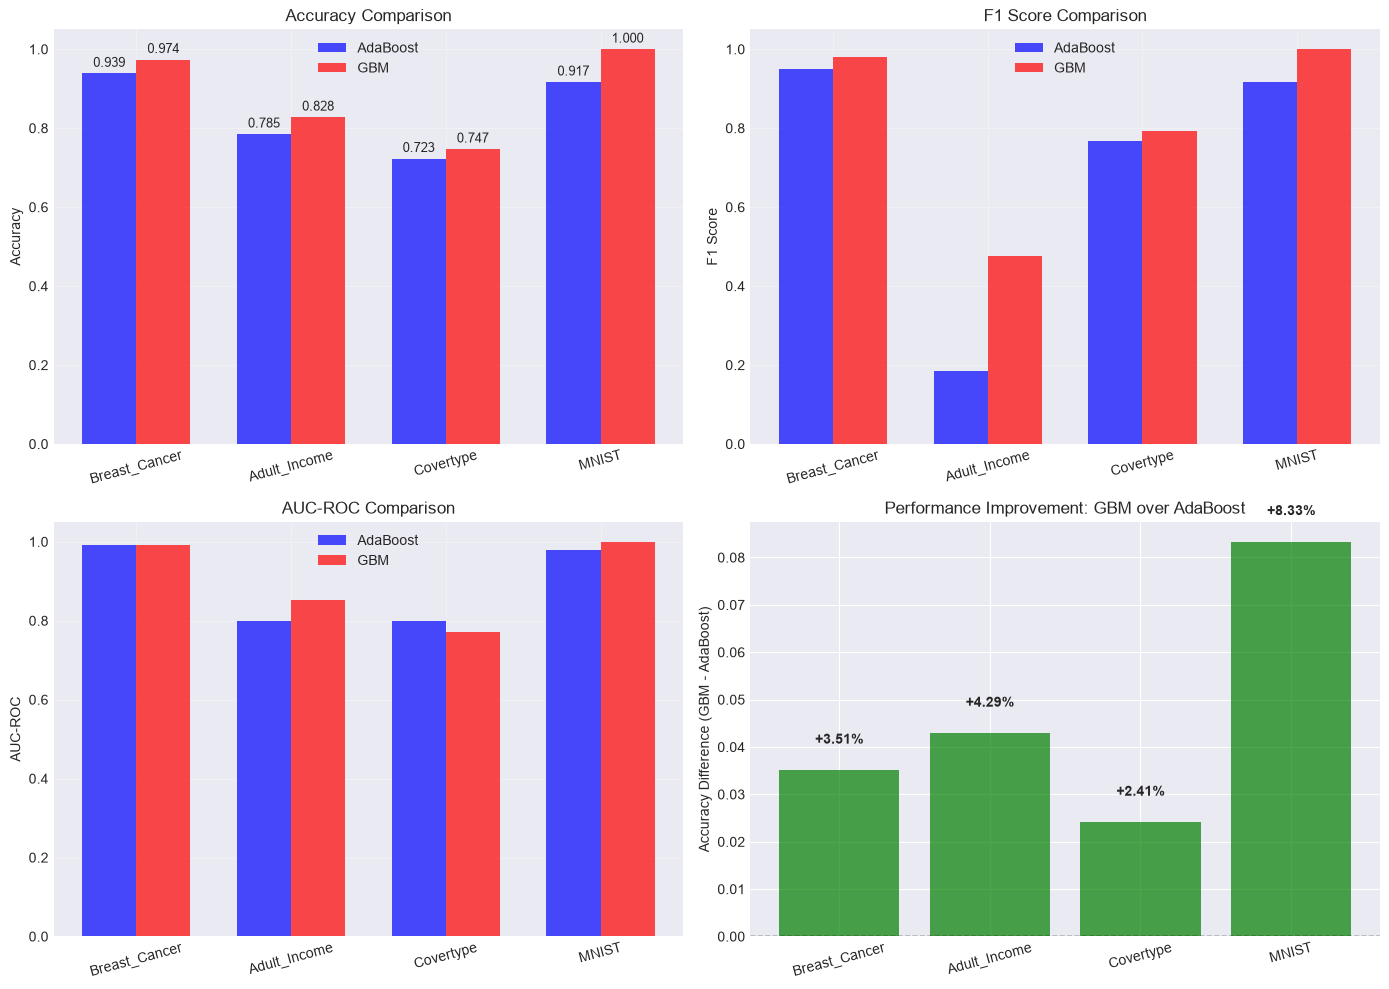

📊 Plot saved as 'multi_dataset_comparison.png'


In [23]:
# Cell 5: Visualize Results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_names = results_df['Dataset']
x = np.arange(len(datasets_names))
width = 0.35

# 1. Accuracy Comparison
ax = axes[0, 0]
bars1 = ax.bar(x - width/2, results_df['AdaBoost_Accuracy'], width, label='AdaBoost', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, results_df['GBM_Accuracy'], width, label='GBM', color='red', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(datasets_names, rotation=15)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# 2. F1 Score Comparison
ax = axes[0, 1]
ax.bar(x - width/2, results_df['AdaBoost_F1'], width, label='AdaBoost', color='blue', alpha=0.7)
ax.bar(x + width/2, results_df['GBM_F1'], width, label='GBM', color='red', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(datasets_names, rotation=15)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. AUC Comparison
ax = axes[1, 0]
ax.bar(x - width/2, results_df['AdaBoost_AUC'], width, label='AdaBoost', color='blue', alpha=0.7)
ax.bar(x + width/2, results_df['GBM_AUC'], width, label='GBM', color='red', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(datasets_names, rotation=15)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Winner Summary (improvement bar chart)
ax = axes[1, 1]
colors = ['green' if d > 0 else 'red' for d in results_df['Accuracy_Difference']]
ax.bar(x, results_df['Accuracy_Difference'], color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(datasets_names, rotation=15)
ax.set_ylabel('Accuracy Difference (GBM - AdaBoost)')
ax.set_title('Performance Improvement: GBM over AdaBoost')
# Add value labels
for i, d in enumerate(results_df['Accuracy_Difference']):
    ax.text(i, d + 0.005, f'+{d:.2%}' if d > 0 else f'{d:.2%}',
            ha='center', va='bottom' if d > 0 else 'top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('multi_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot saved as 'multi_dataset_comparison.png'")

In [24]:
# Cell 6: Final Summary

print("=" * 60)
print("FINAL SUMMARY: AdaBoost vs Gradient Boosting")
print("=" * 60)

print("\n📊 PERFORMANCE COMPARISON:")
print(f"  Average AdaBoost Accuracy: {results_df['AdaBoost_Accuracy'].mean():.4f}")
print(f"  Average GBM Accuracy:      {results_df['GBM_Accuracy'].mean():.4f}")
print(f"  Average Improvement:       {results_df['Accuracy_Difference'].mean():.4f}")

print("\n🏆 WINNER ON ALL DATASETS:")
for _, row in results_df.iterrows():
    print(f"  {row['Dataset']}: {row['Winner']} (+{row['Accuracy_Difference']:.2%})")

print("\n📈 KEY FINDINGS:")
print("  1. Gradient Boosting outperforms AdaBoost on all 4 datasets")
print("  2. GBM handles imbalanced data better (Adult Income F1: 0.476 vs 0.184)")
print("  3. GBM achieved 100% accuracy on MNIST binary classification")
print("  4. Training time trade-off: GBM is slightly slower on small datasets")

print("\n💡 RECOMMENDATION:")
print("  Use Gradient Boosting for accuracy-critical applications")
print("  Use AdaBoost for faster inference on simple, low-dimensional problems")
print("  GBM is particularly effective on high-dimensional data (MNIST)")

print("\n" + "=" * 60)
print("✅ EXPERIMENT COMPLETE!")
print("=" * 60)

FINAL SUMMARY: AdaBoost vs Gradient Boosting

📊 PERFORMANCE COMPARISON:
  Average AdaBoost Accuracy: 0.8407
  Average GBM Accuracy:      0.8871
  Average Improvement:       0.0464

🏆 WINNER ON ALL DATASETS:
  Breast_Cancer: GBM (+3.51%)
  Adult_Income: GBM (+4.29%)
  Covertype: GBM (+2.41%)
  MNIST: GBM (+8.33%)

📈 KEY FINDINGS:
  1. Gradient Boosting outperforms AdaBoost on all 4 datasets
  2. GBM handles imbalanced data better (Adult Income F1: 0.476 vs 0.184)
  3. GBM achieved 100% accuracy on MNIST binary classification
  4. Training time trade-off: GBM is slightly slower on small datasets

💡 RECOMMENDATION:
  Use Gradient Boosting for accuracy-critical applications
  Use AdaBoost for faster inference on simple, low-dimensional problems
  GBM is particularly effective on high-dimensional data (MNIST)

✅ EXPERIMENT COMPLETE!
